In [ ]:
# ==============================================================================
# 1. 라이브러리 설치 및 데이터 다운로드
# ==============================================================================

!pip install efficientnet_pytorch
!pip install torchmetrics
!pip install kagglehub  

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
import kagglehub 
import time
import copy
from google.colab import drive
from collections import Counter 
from google.colab import drive 

# 다운로드 및 경로 설정
path = kagglehub.dataset_download("sujaykapadnis/cucumber-disease-recognition-dataset")

print("다운로드된 데이터셋 경로:", path)

# GPU 사용 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=db884ce9275e80100328216e7961523ac7a7acdb50a0a9d8c09c2a1919275c3a
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.1 MB/s eta 0:00:00
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


100%|██████████| 2.59G/2.59G [00:31<00:00, 89.0MB/s]

Extracting files...


다운로드된 데이터셋 경로: /root/.cache/kagglehub/datasets/sujaykapadnis/cucumber-disease-recognition-dataset/versions/1
사용 장치: cuda:0


In [ ]:
# ==============================================================================
# 2. 데이터셋 경로 설정
# ==============================================================================
import os


DATA_ROOT_DOWNLOAD = path
print(f"DEBUG: 다운로드 루트 경로: {DATA_ROOT_DOWNLOAD}")


INTERMEDIATE_FOLDER = 'Cucumber Disease Recognition Dataset'
INTERMEDIATE_PATH = os.path.join(DATA_ROOT_DOWNLOAD, INTERMEDIATE_FOLDER)


AUGMENTED_FOLDER_1 = 'Augmented Image'
AUGMENTED_FOLDER_2 = 'Augmented Image' 


DATA_ROOT_FOR_SPLIT = os.path.join(INTERMEDIATE_PATH, AUGMENTED_FOLDER_1, AUGMENTED_FOLDER_2)

print(f"\n✅ 최종 데이터 로드 경로 (DATA_ROOT_FOR_SPLIT): {DATA_ROOT_FOR_SPLIT}")



if not os.path.exists(DATA_ROOT_FOR_SPLIT):
    print(f"❌ 오류: DATA_ROOT_FOR_SPLIT 경로를 찾을 수 없습니다: {DATA_ROOT_FOR_SPLIT}")
else:
    print(f"✅ 경로 확인 완료: {DATA_ROOT_FOR_SPLIT}")
    print("     '4. 데이터 로드' 섹션을 실행하세요.")

DEBUG: 다운로드 루트 경로: /root/.cache/kagglehub/datasets/sujaykapadnis/cucumber-disease-recognition-dataset/versions/1

✅ 최종 데이터 로드 경로 (DATA_ROOT_FOR_SPLIT): /root/.cache/kagglehub/datasets/sujaykapadnis/cucumber-disease-recognition-dataset/versions/1/Cucumber Disease Recognition Dataset/Augmented Image/Augmented Image
✅ 경로 확인 완료: /root/.cache/kagglehub/datasets/sujaykapadnis/cucumber-disease-recognition-dataset/versions/1/Cucumber Disease Recognition Dataset/Augmented Image/Augmented Image
     '4. 데이터 로드' 섹션을 실행하세요.


In [ ]:
# ==============================================================================
# 3. 하이퍼파라미터 및 데이터 변환 설정 
# ==============================================================================
from efficientnet_pytorch import EfficientNet

# 하이퍼파라미터
BATCH_SIZE = 32 
NUM_EPOCHS = 10
LEARNING_RATE = 0.0001
MODEL_NAME = 'efficientnet-b0' 


INPUT_SIZE = EfficientNet.get_image_size(MODEL_NAME)

# 데이터 증강 및 정규화
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.RandomResizedCrop(INPUT_SIZE),
        
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
    ]),
    'test': transforms.Compose([
        transforms.Resize(INPUT_SIZE),
        transforms.CenterCrop(INPUT_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [ ]:
# ==============================================================================
# 4. 데이터 로드 및 DataLoader 생성 
# ==============================================================================
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

print("\n데이터 로딩 및 안전한 90:10 분할 중...")


full_dataset = ImageFolder(DATA_ROOT_FOR_SPLIT, data_transforms['train']) 
full_size = len(full_dataset)


train_size = int(0.9 * full_size)
val_size = full_size - train_size


train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)


dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),
    
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
}


dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print(f"클래스 개수: {NUM_CLASSES}")
print(f"클래스 이름: {class_names}")
print(f"✅ 새로운 학습 데이터 크기: {dataset_sizes['train']} (90%)")
print(f"✅ 새로운 검증 데이터 크기: {dataset_sizes['val']} (10%)")


데이터 로딩 및 안전한 90:10 분할 중...
클래스 개수: 8
클래스 이름: ['Anthracnose', 'Bacterial Wilt', 'Belly Rot', 'Downy Mildew', 'Fresh Cucumber', 'Fresh Leaf', 'Gummy Stem Blight', 'Pythium Fruit Rot']
✅ 새로운 학습 데이터 크기: 5760 (90%)
✅ 새로운 검증 데이터 크기: 640 (10%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
# ==============================================================================
# 5. 모델 설정 및 가중치 부여 손실 함수 설정 
# ==============================================================================
from collections import Counter
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

# ==============================================================================
# 1. 클래스 가중치 계산 
# ==============================================================================
from collections import Counter


train_targets = full_dataset.targets 
class_counts = Counter(train_targets)
total_count = sum(class_counts.values())

class_weights = [total_count / class_counts[i] for i in range(NUM_CLASSES)]
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights = class_weights / class_weights.min()

print(f"✅ 클래스 가중치 계산 완료: {class_weights.tolist()}")


# ----------------------------------------------------------------------
# 2. EfficientNet-B0 모델 로드 및 분류 레이어 명시적 교체 
# ----------------------------------------------------------------------


model_ft = EfficientNet.from_pretrained(MODEL_NAME).to(device)


num_ftrs = model_ft._fc.in_features


model_ft._fc = nn.Sequential(
    nn.Dropout(0.5), 
    nn.Linear(num_ftrs, NUM_CLASSES)
)

model_ft = model_ft.to(device) 

print(f"✅ EfficientNet-B0의 최종 분류 레이어(w/ Dropout)가 {num_ftrs} -> {NUM_CLASSES}로 성공적으로 교체되었습니다.")


# ----------------------------------------------------------------------
# 3. Loss, Optimizer, Scheduler 정의
# ----------------------------------------------------------------------


criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))


optimizer_ft = optim.AdamW(model_ft.parameters(), lr=LEARNING_RATE)


exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=8, gamma=0.5)

print("✅ Loss, Optimizer, Scheduler 정의 완료.")


✅ 클래스 가중치 계산 완료: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 65.0MB/s]


Loaded pretrained weights for efficientnet-b0
✅ EfficientNet-B0의 최종 분류 레이어(w/ Dropout)가 1280 -> 8로 성공적으로 교체되었습니다.
✅ Loss, Optimizer, Scheduler 정의 완료.


In [ ]:
# ==============================================================================
# 6. 모델 학습 함수 
# ==============================================================================
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f'\nEpoch {epoch+1}/{num_epochs}'); print('-' * 10)

        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'-> New best model found! Saving weights with Acc: {best_acc:.4f}')

        epoch_time = time.time() - epoch_start_time
        print(f'Epoch Time: {epoch_time:.0f}초')

    time_elapsed = time.time() - since
    print(f'\n학습 완료! 총 시간: {time_elapsed // 60:.0f}분 {time_elapsed % 60:.0f}초')
    print(f'최고 검증 정확도: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model

In [ ]:
# ==============================================================================
# 7. 모델 학습 실행 및 저장
# ==============================================================================

# 모델 학습 시작
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)


drive.mount('/content/drive')
MODEL_SAVE_PATH = '/content/drive/MyDrive/disease_model.pth' # ⚠️ 파일 이름에 weighted 추가

# 모델 저장
torch.save(model_ft.state_dict(), MODEL_SAVE_PATH)
print(f"\n✅ 최적 모델 가중치가 {MODEL_SAVE_PATH}에 저장되었습니다.")


Epoch 1/10
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


train Loss: 1.1966 Acc: 0.6325
val Loss: 0.4861 Acc: 0.8203
-> New best model found! Saving weights with Acc: 0.8203
Epoch Time: 282초

Epoch 2/10
----------
train Loss: 0.4701 Acc: 0.8425
val Loss: 0.2858 Acc: 0.9000
-> New best model found! Saving weights with Acc: 0.9000
Epoch Time: 280초

Epoch 3/10
----------
train Loss: 0.3137 Acc: 0.8936
val Loss: 0.2079 Acc: 0.9281
-> New best model found! Saving weights with Acc: 0.9281
Epoch Time: 288초

Epoch 4/10
----------
train Loss: 0.2662 Acc: 0.9104


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


val Loss: 0.1821 Acc: 0.9328
-> New best model found! Saving weights with Acc: 0.9328
Epoch Time: 284초

Epoch 5/10
----------
train Loss: 0.2166 Acc: 0.9229
val Loss: 0.1563 Acc: 0.9422
-> New best model found! Saving weights with Acc: 0.9422
Epoch Time: 281초

Epoch 6/10
----------
train Loss: 0.2039 Acc: 0.9356
val Loss: 0.1209 Acc: 0.9547
-> New best model found! Saving weights with Acc: 0.9547
Epoch Time: 284초

Epoch 7/10
----------
train Loss: 0.1816 Acc: 0.9401
val Loss: 0.1234 Acc: 0.9516
Epoch Time: 276초

Epoch 8/10
----------
train Loss: 0.1671 Acc: 0.9439
val Loss: 0.1038 Acc: 0.9594
-> New best model found! Saving weights with Acc: 0.9594
Epoch Time: 279초

Epoch 9/10
----------
train Loss: 0.1450 Acc: 0.9510
val Loss: 0.0757 Acc: 0.9734
-> New best model found! Saving weights with Acc: 0.9734
Epoch Time: 288초

Epoch 10/10
----------
train Loss: 0.1264 Acc: 0.9582
val Loss: 0.0977 Acc: 0.9688
Epoch Time: 284초

학습 완료! 총 시간: 47분 7초
최고 검증 정확도: 0.9734
Mounted at /content/drive

✅ 

In [ ]:
# ==============================================================================
# 8. ONNX 모델 변환 및 저장 
# ==============================================================================

!pip install onnx
!pip install onnxruntime



ONNX_SAVE_PATH = 'cucumber_disease_model.onnx'


model_ft.eval()


dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=device)


try:
    torch.onnx.export(
        model_ft,                   
        dummy_input,                
        ONNX_SAVE_PATH,             
        export_params=True,         
        opset_version=11,           
        do_constant_folding=True,   
        input_names = ['input'],    
        output_names = ['output'],  
        dynamic_axes={'input' : {0 : 'batch_size'},    
                      'output' : {0 : 'batch_size'}}
    )
    print(f"\n✅ 모델이 ONNX 형식으로 {ONNX_SAVE_PATH}에 성공적으로 저장되었습니다.")

except Exception as e:
    print(f"\n❌ ONNX 변환 중 오류 발생: {e}")

/tmp/ipython-input-2416816508.py:24: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(



✅ 모델이 ONNX 형식으로 cucumber_disease_model.onnx에 성공적으로 저장되었습니다.


In [ ]:
import pandas as pd
import os


final_dataset = val_dataset
print(f"최종 평가 데이터 개수: {len(final_dataset)}개")


def create_dataset_metadata(dataset, class_names):
    data_list = []
    if hasattr(dataset, 'indices'):
        for idx in dataset.indices:
            path, label_idx = dataset.dataset.samples[idx]
            data_list.append({
                'file_path': path,
                'file_name': os.path.basename(path),
                'label_index': label_idx,
                'class_name': class_names[label_idx]
            })
    else:
        for path, label_idx in dataset.samples:
            data_list.append({
                'file_path': path,
                'file_name': os.path.basename(path),
                'label_index': label_idx,
                'class_name': class_names[label_idx]
            })
    return pd.DataFrame(data_list)

# 3. CSV 저장
df_final = create_dataset_metadata(final_dataset, class_names)
df_final.to_csv('final_cucumber_dataset_metadata.csv', index=False, encoding='utf-8-sig') # 파일명 변경
print("✅ 메타데이터 저장 완료")

최종 평가 데이터 개수: 640개
✅ 메타데이터 저장 완료


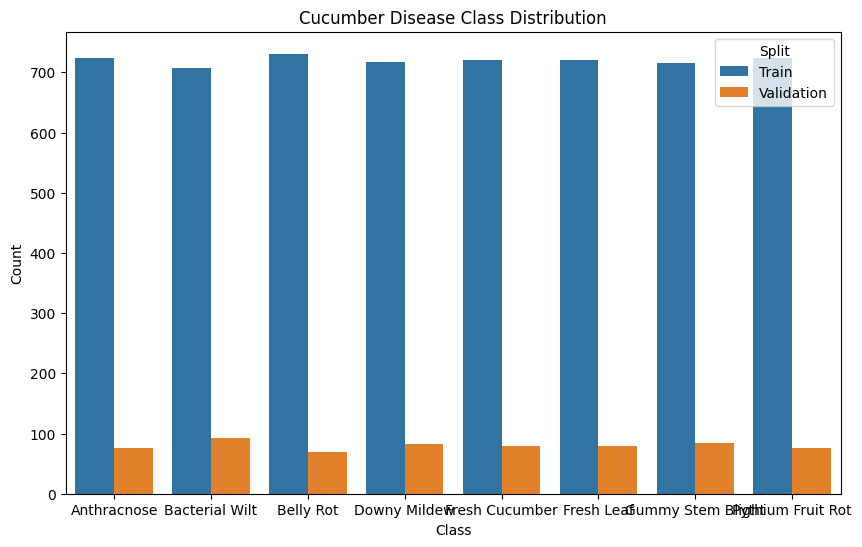

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def get_label_counts(dataset):
    if hasattr(dataset, 'indices'):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets
    return Counter(labels)

train_counts = get_label_counts(train_dataset)
val_counts = get_label_counts(val_dataset)

plot_data = []
for idx, name in enumerate(class_names):
    plot_data.append({'Class': name, 'Count': train_counts[idx], 'Split': 'Train'})
    plot_data.append({'Class': name, 'Count': val_counts[idx], 'Split': 'Validation'})
df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Class', y='Count', hue='Split')
plt.title('Cucumber Disease Class Distribution')
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


                   precision    recall  f1-score   support

      Anthracnose       0.93      0.88      0.91        76
   Bacterial Wilt       0.97      0.97      0.97        93
        Belly Rot       0.96      0.97      0.96        69
     Downy Mildew       0.94      0.95      0.95        82
   Fresh Cucumber       0.98      0.99      0.98        80
       Fresh Leaf       0.95      1.00      0.98        80
Gummy Stem Blight       0.92      0.90      0.91        84
Pythium Fruit Rot       1.00      0.97      0.99        76

         accuracy                           0.95       640
        macro avg       0.95      0.95      0.95       640
     weighted avg       0.95      0.95      0.95       640



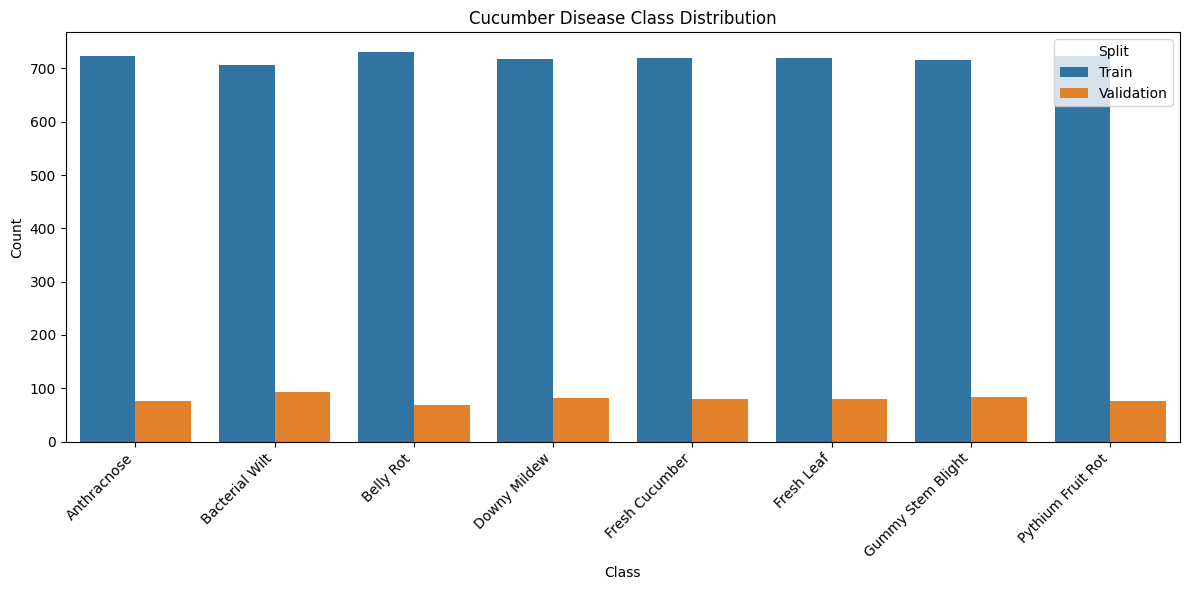

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

model_ft.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 6)) 
sns.barplot(data=df_plot, x='Class', y='Count', hue='Split')
plt.title('Cucumber Disease Class Distribution')


plt.xticks(rotation=45, ha='right')

plt.tight_layout() 
plt.show()

특징 추출 중...


  0%|          | 0/20 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 20/20 [00:26<00:00,  1.32s/it]


t-SNE 변환 중...


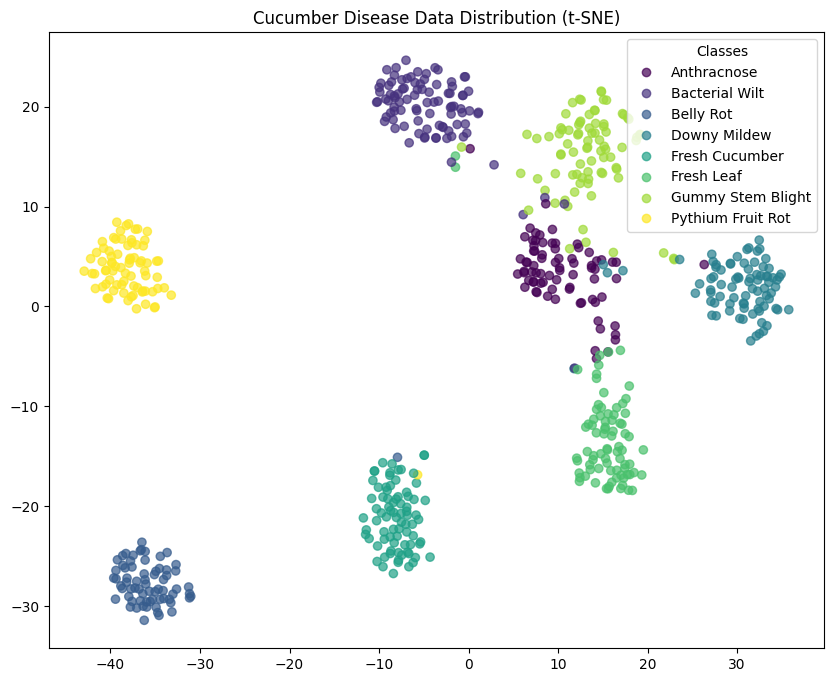

In [ ]:
from sklearn.manifold import TSNE
from tqdm import tqdm

def get_features_and_labels(model, dataloader, device):
    model.eval()
    features = []
    labels_list = []

    print("특징 추출 중...")
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            
            feature_map = model.extract_features(inputs)
            
            feature_vec = model._avg_pooling(feature_map).flatten(start_dim=1)

            features.append(feature_vec.cpu().numpy())
            labels_list.append(labels.numpy())

    return np.concatenate(features, axis=0), np.concatenate(labels_list, axis=0)

features, labels = get_features_and_labels(model_ft, dataloaders['val'], device)

print("t-SNE 변환 중...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Classes")
plt.title("Cucumber Disease Data Distribution (t-SNE)")
plt.show()

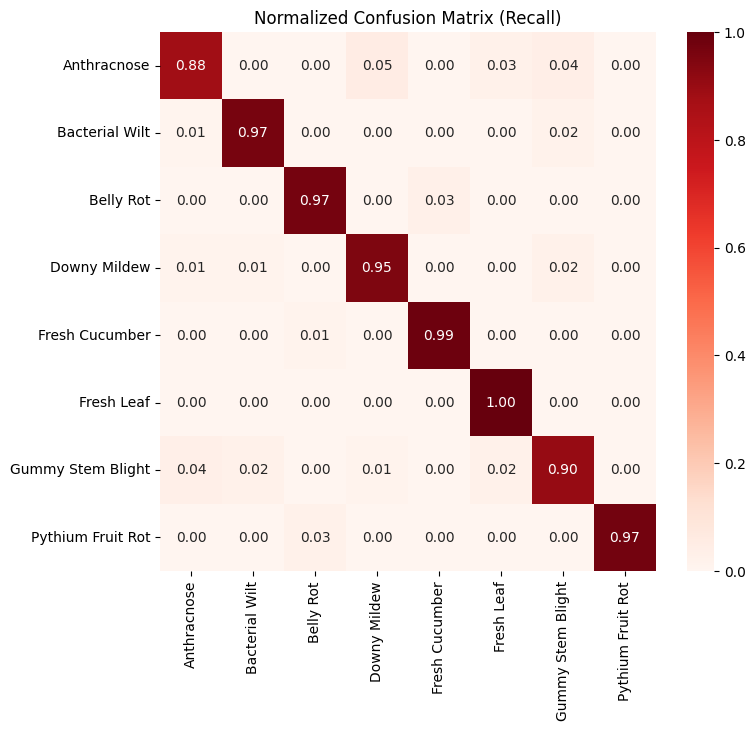

In [16]:
# 정규화된 혼동 행렬
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(8, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Recall)')
plt.show()